In [18]:
!pip -q install "transformers==4.44.2" "bert-score==0.3.13" "tokenizers==0.19.1"
print('installed — now restart the session')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 28.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
installed — now restart the session


In [1]:
import time, math, random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

from nltk.translate.bleu_score import corpus_bleu
from bert_score import score as bert_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

cuda


Upload files

In [6]:
try:
    from google.colab import files
    files.upload()
except Exception:
    pass

Saving dev_en_1000.csv to dev_en_1000.csv
Saving dev_sa_1000.csv to dev_sa_1000.csv
Saving test_en_1000.csv to test_en_1000.csv
Saving test_sa_1000.csv to test_sa_1000.csv
Saving train_en_10000.csv to train_en_10000.csv
Saving train_sa_10000.csv to train_sa_10000.csv


Load Data

In [2]:
DATA_DIR = '/content/'

def load(sa_file, en_file):
    sa = pd.read_csv(DATA_DIR + sa_file, encoding='utf-8-sig')
    en = pd.read_csv(DATA_DIR + en_file, encoding='utf-8-sig')
    sa.columns = [c.strip() for c in sa.columns]
    en.columns = [c.strip() for c in en.columns]
    df = sa.merge(en, on='Source_id').dropna(subset=['Sentence_sa', 'Sentence_en'])
    df = df.reset_index(drop=True)
    df['Sentence_sa'] = df['Sentence_sa'].astype(str).str.strip()
    df['Sentence_en'] = df['Sentence_en'].astype(str).str.strip()
    return df

train_df = load('train_sa_10000.csv', 'train_en_10000.csv')
dev_df   = load('dev_sa_1000.csv',    'dev_en_1000.csv')
test_df  = load('test_sa_1000.csv',   'test_en_1000.csv')
print(len(train_df), len(dev_df), len(test_df))
train_df.head()

10000 1000 1000


,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."
3,4,वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।,I will choose Colors options by clicking on it.
4,5,"""अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...","""See the example here - one mountain, four vil..."


tokenizers & vocab

In [3]:
def tok_sa(t):
    return list(t.strip())

def tok_en(t):
    return t.lower().strip().split()

PAD_IDX, UNK_IDX, SOS_IDX, EOS_IDX = 0, 1, 2, 3

class Vocab:
    def __init__(self, min_freq=1):
        self.min_freq = min_freq
        self.stoi = {'<pad>': 0, '<unk>': 1, '<sos>': 2, '<eos>': 3}
        self.itos = {i: t for t, i in self.stoi.items()}

    def build(self, sentences, tok):
        c = Counter()
        for s in sentences:
            c.update(tok(s))
        for w, f in c.items():
            if f >= self.min_freq and w not in self.stoi:
                i = len(self.stoi)
                self.stoi[w] = i
                self.itos[i] = w
        return self

    def encode(self, toks):
        return [self.stoi.get(t, UNK_IDX) for t in toks]

    def decode(self, ids):
        skip = {PAD_IDX, UNK_IDX, SOS_IDX, EOS_IDX}
        return [self.itos.get(i, '<unk>') for i in ids if i not in skip]

    def __len__(self):
        return len(self.stoi)

src_vocab = Vocab(min_freq=1).build(train_df['Sentence_sa'], tok_sa)
tgt_vocab = Vocab(min_freq=2).build(train_df['Sentence_en'], tok_en)   # drop rare english words
print('src', len(src_vocab), '| tgt', len(tgt_vocab))

src 194 | tgt 7072


dataset & dataloaders

In [7]:
MAX_SRC, MAX_TGT = 180, 60

class NMTData(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        src = src_vocab.encode(tok_sa(r['Sentence_sa'])[:MAX_SRC]) or [UNK_IDX]
        tgt = [SOS_IDX] + tgt_vocab.encode(tok_en(r['Sentence_en'])[:MAX_TGT]) + [EOS_IDX]
        return torch.tensor(src), torch.tensor(tgt)

def collate(batch):
    src, tgt = zip(*batch)
    src_len = torch.tensor([len(x) for x in src])
    src = nn.utils.rnn.pad_sequence(src, batch_first=True, padding_value=PAD_IDX)
    tgt = nn.utils.rnn.pad_sequence(tgt, batch_first=True, padding_value=PAD_IDX)
    return src, tgt, src_len

BATCH = 64
train_loader = DataLoader(NMTData(train_df), BATCH, shuffle=True,  collate_fn=collate)
dev_loader   = DataLoader(NMTData(dev_df),   BATCH, shuffle=False, collate_fn=collate)
print(len(train_loader), len(dev_loader))

157 16


model (encoder, attention, decoder, seq2seq)

In [4]:
class Encoder(nn.Module):
    def __init__(self, vocab, emb, enc_h, dec_h, dropout):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb, padding_idx=PAD_IDX)
        self.rnn = nn.GRU(emb, enc_h, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(enc_h * 2, dec_h)
        self.drop = nn.Dropout(dropout)

    def forward(self, src, src_len):
        e = self.drop(self.emb(src))
        packed = pack_padded_sequence(e, src_len.cpu(), batch_first=True, enforce_sorted=False)
        out, h = self.rnn(packed)
        out, _ = pad_packed_sequence(out, batch_first=True)
        h = torch.tanh(self.fc(torch.cat([h[-2], h[-1]], dim=1)))   # combine both directions
        return out, h

class Attention(nn.Module):
    def __init__(self, enc_h, dec_h):
        super().__init__()
        self.attn = nn.Linear(enc_h * 2 + dec_h, dec_h)
        self.v = nn.Linear(dec_h, 1, bias=False)

    def forward(self, hidden, enc_out, mask):
        S = enc_out.shape[1]
        h = hidden.unsqueeze(1).repeat(1, S, 1)
        e = torch.tanh(self.attn(torch.cat([h, enc_out], dim=2)))
        score = self.v(e).squeeze(2).masked_fill(mask == 0, -1e10)
        return F.softmax(score, dim=1)

class Decoder(nn.Module):
    def __init__(self, vocab, emb, enc_h, dec_h, dropout):
        super().__init__()
        self.vocab = vocab
        self.emb = nn.Embedding(vocab, emb, padding_idx=PAD_IDX)
        self.attn = Attention(enc_h, dec_h)
        self.rnn = nn.GRU(emb + enc_h * 2, dec_h, batch_first=True)
        self.fc = nn.Linear(dec_h + enc_h * 2 + emb, vocab)
        self.drop = nn.Dropout(dropout)

    def forward(self, tok, hidden, enc_out, mask):
        tok = tok.unsqueeze(1)
        e = self.drop(self.emb(tok))
        a = self.attn(hidden, enc_out, mask).unsqueeze(1)
        ctx = torch.bmm(a, enc_out)
        out, h = self.rnn(torch.cat([e, ctx], dim=2), hidden.unsqueeze(0))
        pred = self.fc(torch.cat([out.squeeze(1), ctx.squeeze(1), e.squeeze(1)], dim=1))
        return pred, h.squeeze(0)

class Seq2Seq(nn.Module):
    def __init__(self, enc, dec):
        super().__init__()
        self.enc = enc
        self.dec = dec

    def mask(self, src):
        return src != PAD_IDX

    def forward(self, src, src_len, tgt, tf_ratio=0.5):
        B, T = tgt.shape
        outputs = torch.zeros(B, T, self.dec.vocab, device=src.device)
        m = self.mask(src)
        enc_out, hidden = self.enc(src, src_len)
        inp = tgt[:, 0]
        for t in range(1, T):
            pred, hidden = self.dec(inp, hidden, enc_out, m)
            outputs[:, t] = pred
            inp = tgt[:, t] if random.random() < tf_ratio else pred.argmax(1)
        return outputs

build the model

In [5]:
EMB, ENC_H, DEC_H, DROP = 128, 256, 256, 0.3
LR, EPOCHS, CLIP = 3e-4, 30, 1.0

enc = Encoder(len(src_vocab), EMB, ENC_H, DEC_H, DROP)
dec = Decoder(len(tgt_vocab), EMB, ENC_H, DEC_H, DROP)
model = Seq2Seq(enc, dec).to(device)

for _, p in model.named_parameters():
    nn.init.uniform_(p.data, -0.08, 0.08)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('parameters:', f'{n_params:,}')

parameters: 8,884,640


Train - 30 Epoch

In [12]:
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

def run(loader, train):
    model.train() if train else model.eval()
    total = 0.0
    tf = 0.5 if train else 0.0
    with torch.set_grad_enabled(train):
        for src, tgt, src_len in loader:
            src, tgt = src.to(device), tgt.to(device)
            if train:
                optimizer.zero_grad()
            out = model(src, src_len, tgt, tf)
            V = out.shape[-1]
            loss = criterion(out[:, 1:].reshape(-1, V), tgt[:, 1:].reshape(-1))
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CLIP)
                optimizer.step()
            total += loss.item()
    return total / len(loader)

best = float('inf')
train_hist, dev_hist = [], []
for ep in range(1, EPOCHS + 1):
    t0 = time.time()
    tr = run(train_loader, True)
    dv = run(dev_loader, False)
    scheduler.step(dv)
    train_hist.append(tr)
    dev_hist.append(dv)
    if dv < best:
        best = dv
        torch.save(model.state_dict(), 'best_model.pt')
    print(f'epoch {ep:02d}  train {tr:.3f}  dev {dv:.3f}  ppl {math.exp(dv):.1f}  {time.time()-t0:.0f}s')

epoch 01  train 6.487  dev 5.777  ppl 322.9  52s
epoch 02  train 5.994  dev 5.658  ppl 286.7  55s
epoch 03  train 5.816  dev 5.508  ppl 246.5  55s
epoch 04  train 5.616  dev 5.443  ppl 231.0  55s
epoch 05  train 5.481  dev 5.406  ppl 222.8  55s
epoch 06  train 5.349  dev 5.395  ppl 220.2  55s
epoch 07  train 5.241  dev 5.344  ppl 209.4  56s
epoch 08  train 5.145  dev 5.337  ppl 208.0  55s
epoch 09  train 5.068  dev 5.291  ppl 198.6  55s
epoch 10  train 4.993  dev 5.308  ppl 201.9  56s
epoch 11  train 4.926  dev 5.285  ppl 197.4  56s
epoch 12  train 4.858  dev 5.267  ppl 193.9  56s
epoch 13  train 4.756  dev 5.289  ppl 198.1  56s
epoch 14  train 4.704  dev 5.293  ppl 199.0  56s
epoch 15  train 4.651  dev 5.278  ppl 195.9  56s
epoch 16  train 4.548  dev 5.257  ppl 191.9  55s
epoch 17  train 4.500  dev 5.264  ppl 193.3  56s
epoch 18  train 4.477  dev 5.254  ppl 191.4  56s
epoch 19  train 4.447  dev 5.257  ppl 192.0  55s
epoch 20  train 4.412  dev 5.263  ppl 193.0  55s
epoch 21  train 4.37

training curves

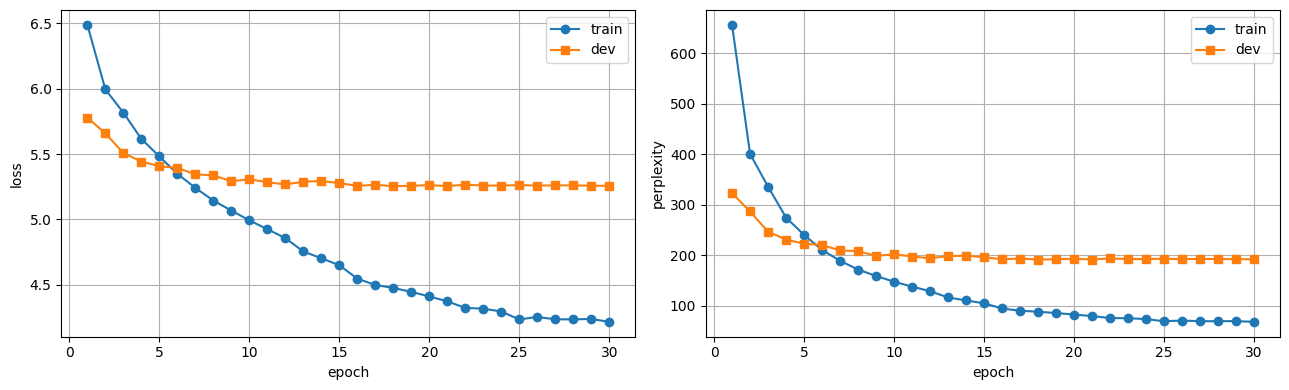

In [13]:
x = range(1, len(train_hist) + 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(x, train_hist, 'o-', label='train'); ax[0].plot(x, dev_hist, 's-', label='dev')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('loss'); ax[0].legend(); ax[0].grid(True)
ax[1].plot(x, [math.exp(l) for l in train_hist], 'o-', label='train')
ax[1].plot(x, [math.exp(l) for l in dev_hist], 's-', label='dev')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('perplexity'); ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.savefig('training_curves.png', dpi=150); plt.show()

beam search decoder

In [11]:
def beam_search(src_ids, beam=5, max_len=MAX_TGT, alpha=0.7):
    model.eval()
    with torch.no_grad():
        src = torch.tensor([src_ids], device=device)
        src_len = torch.tensor([len(src_ids)])
        mask = model.mask(src)
        enc_out, hidden = model.enc(src, src_len)
        beams = [(0.0, [SOS_IDX], hidden)]
        done = []
        for step in range(max_len):
            cand = []
            for score, seq, h in beams:
                if seq[-1] == EOS_IDX:
                    done.append((score, seq)); continue
                inp = torch.tensor([seq[-1]], device=device)
                pred, h2 = model.dec(inp, h, enc_out, mask)
                logp = F.log_softmax(pred, dim=-1).squeeze(0)
                logp[PAD_IDX] = logp[UNK_IDX] = logp[SOS_IDX] = -1e9   # never emit these
                if len(seq) == 1:
                    logp[EOS_IDX] = -1e9                               # force at least one word
                lp, ix = logp.topk(beam)
                for a, b in zip(lp.tolist(), ix.tolist()):
                    cand.append((score + a, seq + [b], h2))
            if not cand:
                break
            cand.sort(key=lambda z: z[0] / (len(z[1]) ** alpha), reverse=True)   # length penalty
            beams = cand[:beam]
        done += [(s, seq) for s, seq, _ in beams]
        best = max(done, key=lambda z: z[0] / (len(z[1]) ** alpha))
        return ' '.join(tgt_vocab.decode(best[1]))

def translate(df, beam=5):
    out = []
    for i in range(len(df)):
        ids = src_vocab.encode(tok_sa(df.iloc[i]['Sentence_sa'])[:MAX_SRC]) or [UNK_IDX]
        out.append(beam_search(ids, beam))
    return out

dev predictions + BLEU

In [20]:
model.load_state_dict(torch.load('best_model.pt', map_location=device))
dev_pred = translate(dev_df, beam=5)

refs = [[r.lower().split()] for r in dev_df['Sentence_en']]
hyps = [h.split() for h in dev_pred]
print('dev BLEU:', round(corpus_bleu(refs, hyps), 4))   # default nltk bleu, no weights

dev BLEU: 0.0286


 dev BERTScore

In [21]:
_, _, F1 = bert_score(dev_pred, dev_df['Sentence_en'].tolist(), lang='en',
                      rescale_with_baseline=True, use_fast_tokenizer=True)
print('dev BERTScore F1:', round(F1.mean().item(), 4))

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


dev BERTScore F1: 0.0478


 test predictions + submission.csv

In [22]:
t0 = time.time()
test_pred = translate(test_df, beam=5)
test_time = time.time() - t0

if test_df['Sentence_en'].notna().any() and (test_df['Sentence_en'].str.len() > 0).any():
    refs = [[r.lower().split()] for r in test_df['Sentence_en']]
    hyps = [h.split() for h in test_pred]
    print('test BLEU:', round(corpus_bleu(refs, hyps), 4))
    _, _, F1 = bert_score(test_pred, test_df['Sentence_en'].tolist(), lang='en',
                          rescale_with_baseline=True, use_fast_tokenizer=True)
    print('test BERTScore F1:', round(F1.mean().item(), 4))

submission = pd.DataFrame({'Source_id': test_df['Source_id'].values, 'Sentence_en': test_pred})
submission.to_csv('submission.csv', index=False, encoding='utf-8')
print('submission.csv:', len(submission), 'rows')
submission.head()

test BLEU: 0.0271


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


test BERTScore F1: 0.0519
submission.csv: 1000 rows


,Source_id,Sentence_en
0,1,it is the spoken tutorial on the
1,2,"""for this is not to the the of of the of the a..."
2,3,"so, we have to the the of the and i will click..."
3,4,"to record this tutorial, i am using: ubuntu mh..."
4,5,"""and when he was a man that ye shall be able t..."


efficiency (params + test inference time)

In [23]:
print('total parameters       :', f'{n_params:,}')
print('test inference time (s) :', round(test_time, 2), f'for {len(test_df)} sentences')
print('per sentence (ms)       :', round(test_time / len(test_df) * 1000, 1))

total parameters       : 8,884,640
test inference time (s) : 232.34 for 1000 sentences
per sentence (ms)       : 232.3


 example translations

In [24]:
for i in range(8):
    print('SA  :', dev_df.iloc[i]['Sentence_sa'])
    print('REF :', dev_df.iloc[i]['Sentence_en'])
    print('PRED:', dev_pred[i])
    print()

SA  : ते वीराः ।
REF : Those are brave men.
PRED: those two are drums.

SA  : 'इन्फ़ैनेट् लूप्' इतीदं व्यवस्थां निरुत्तरां कारयति ।
REF : Infinite loop  can cause the system to become unresponsive.
PRED: the output is the the the

SA  : ततस्तस्य गात्रे निष्ठीवं दत्वा तेन वेत्रेण शिर आजघ्नुः।
REF : "And they spit upon him, and took the reed, and smote him on the head."
PRED: "and when he was to the the of the

SA  : एते तिथी ।
REF : These two are dates.
PRED: these two are

SA  : "बहुविचारेषु जातषु पितर उत्थाय कथितवान्, हे भ्रातरो यथा भिन्नदेशीयलोका मम मुखात् सुसंवादं श्रुत्वा विश्वसन्ति तदर्थं बहुदिनात् पूर्व्वम् ईश्वरोस्माकं मध्ये मां वृत्वा नियुक्तवान्।"
REF : "And when there had been much disputing, Peter rose up, and said unto them, Men and brethren, ye know how that a good while ago God made choice among us, that the Gentiles by my mouth should hear the word of the gospel, and believe."
PRED: "and when he said unto him, and the the of the and of the the and and the and the that ye

In [25]:
try:
    from google.colab import files
    files.download('submission.csv')
    files.download('training_curves.png')
except Exception:
    pass

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>